# Example: Predator-Prey dynamics

Here, we apply the constant minibatch and adaptive minibatch SMC ABC algorithms to estimate parameters for predator prey dynamics given by stochastic Lotka-Volterra with logistic growth in the prey population. For speed, we apply a vectorized Tau Leaping algorithm, limiting simulation time considerably for off-particle choices. The dynamics are given by the reaction network: 

In [1]:
#Inference classes
from smc_abc import smc_abc_iterator as abc_iter
import smc_abc_utils as utils
import smc_abc_schemes as schemes

#Simulator classes
import predator_prey
lv_sim = predator_prey.lotka_volterra

#Support
import numpy as np
from matplotlib import pyplot as plt


cwd appended to system path


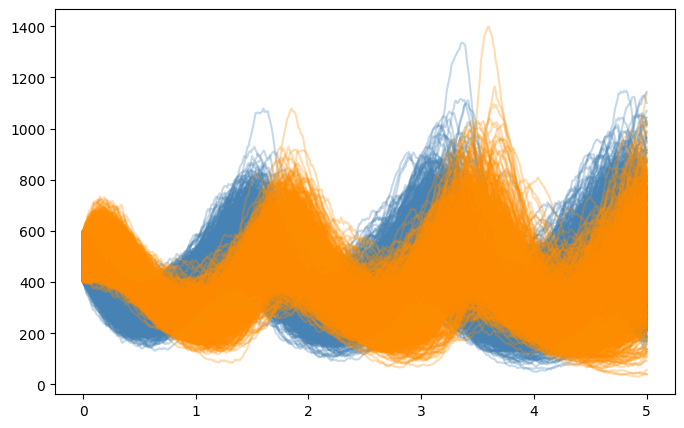

In [2]:
## Setup and tau leaping example
sample_size = 1000
alpha,beta,gamma,delta = 4,0.01,4,1
t_max = 5
dt = 0.01
ic = np.random.uniform(400,600,size=(sample_size,2))

times,ts = lv_sim.tau_leaping(ic,t_max,alpha,beta,gamma,delta,dt = dt,K = 10000)

fig,ax = plt.subplots(figsize = (8,5))
ax.plot(times,ts[:,:,0].T,color = 'steelblue',alpha = 0.3);
ax.plot(times,ts[:,:,1].T,color = 'darkorange',alpha = 0.3);

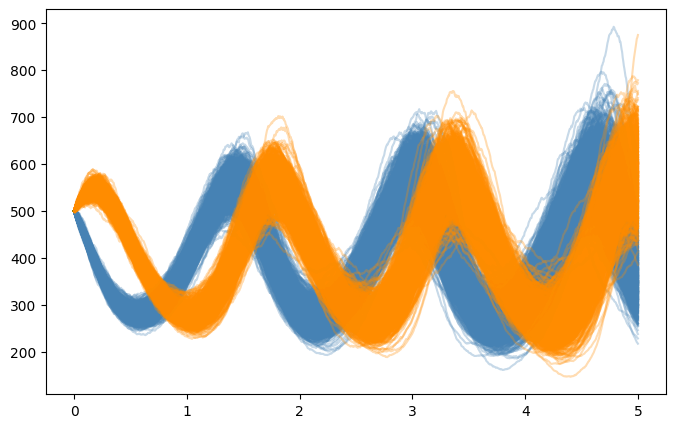

In [3]:
sigma = np.array([0.05,0.05])
times,ts = lv_sim.euler_maruyama(500*np.ones((sample_size,2)),t_max,alpha,beta,gamma,delta,sigma,dt = dt/2)

fig,ax = plt.subplots(figsize = (8,5))
ax.plot(times,ts[:,:,0].T,color = 'steelblue',alpha = 0.3);
ax.plot(times,ts[:,:,1].T,color = 'darkorange',alpha = 0.3);

data

In [35]:
## Setup and tau leaping example
sample_size = 2000
alpha,beta,gamma,delta = 4,0.01,4,1
K = 10000
t_max = 5
dt = 0.01
ic = np.random.uniform(400,600,size=(sample_size,2))

times,data = lv_sim.tau_leaping(ic,t_max,alpha,beta,gamma,delta,dt = dt,K = K)

print(np.sum(np.any(np.any(data == 0,axis=0),axis=1)))

0


In [36]:
#general parameters
num_particles = 300
cores = 4

##model
def model(p,Bi):
    alpha,beta,gamma = list(p)
    _,sim = lv_sim.tau_leaping(ic[Bi],t_max,alpha,beta,gamma,delta,dt = dt, K = K)
    obs = data[Bi]
    return sim, obs


#Stats function
def batch_corr(a, b):
    """Vectorized correlation between rows of a and b"""
    ma = a - np.mean(a, axis=1, keepdims=True)
    mb = b - np.mean(b, axis=1, keepdims=True)
    
    num = np.sum(ma * mb, axis=1)
    den = np.sqrt(np.sum(ma**2, axis=1) * np.sum(mb**2, axis=1))
    return num / (den + 1e-8)

def stats_func_lv(x, max_lag=5, step_size=10):
    r = x[:, :, 0]
    f = x[:, :, 1]
    
    # 1. Base Moments (Per-particle)
    stats_list = [
        np.log(np.mean(r, axis=1) + 1e-8),
        np.log(np.mean(f, axis=1) + 1e-8),
        np.log(np.var(r, axis=1) + 1),
        batch_corr(r, f) # Cross-correlation
    ]

    # 2. Add multiple Autocorrelation lags
    for i in range(1, max_lag + 1):
        lag = i * step_size # e.g., lags of 10, 20, 30, 40, 50 steps
        stats_list.append(batch_corr(r[:, :-lag], r[:, lag:]))
        stats_list.append(batch_corr(f[:, :-lag], f[:, lag:]))

    return np.column_stack(stats_list)
def stats_func(x,y,sf=stats_func_lv):
    return sf(x),sf(y)

prior = utils.uniform_prior([[0.0,10.0],[0.0,0.05],[0.0,10.0]])


init_params = {
    'data': data,
    'model': model,
    'stats_func':stats_func,
    'prior':prior,
    'num_particles':num_particles,
    'cores':cores
}

Running benchmarks...
Batch 8: 0.029653 sec
Batch 16: 0.030004 sec
Batch 32: 0.032467 sec
Batch 64: 0.037371 sec
Batch 128: 0.048076 sec
Batch 256: 0.069245 sec
Batch 512: 0.110946 sec
Average increase in seconds per sample: 0.0001410962629961432


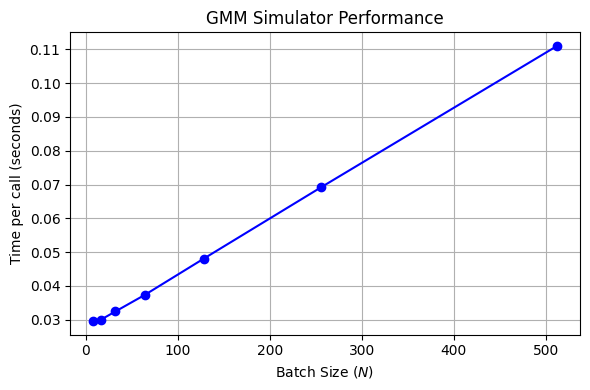

In [22]:
utils.benchmark_time([8,16,32,64,128,256,512],lambda n: model([alpha,beta,gamma],np.random.choice(sample_size,n)))

In [29]:
est = schemes.constant_init(init_params,[10])

while (est.snr > 2) and (est.acceptance_rate > 0.02):
    schemes.constant_loop(est)

700
Generation: 1. Batch Size: 10. Acceptance Rate: 1.000. Step time: 10.241. Total time 10.241. post-filter threshold: 103.7431. ESS: 500.00. Log HDPR vol: 1.088
Estimated v = 2670.622. Noise: v/n = 267.062. v/N = 1.335. Estimated c = 0.157. SNR: eps^2 / (v/n) = 40.300. Time per sim: 0.010
Generation: 2. Batch Size: 10. Acceptance Rate: 0.664. Step time: 12.894. Total time 23.136. post-filter threshold: 48.0221. ESS: 483.29. Log HDPR vol: 0.377
Estimated v = 396.583. Noise: v/n = 39.658. v/N = 0.198. Estimated c = 0.131. SNR: eps^2 / (v/n) = 58.150. Time per sim: 0.009
Generation: 3. Batch Size: 10. Acceptance Rate: 0.520. Step time: 16.320. Total time 39.456. post-filter threshold: 32.4386. ESS: 483.78. Log HDPR vol: -0.086
Estimated v = 115.089. Noise: v/n = 11.509. v/N = 0.058. Estimated c = 0.104. SNR: eps^2 / (v/n) = 91.430. Time per sim: 0.008
Generation: 4. Batch Size: 10. Acceptance Rate: 0.404. Step time: 20.835. Total time 60.291. post-filter threshold: 24.8315. ESS: 482.25.

In [30]:
est = schemes.constant_init(init_params,[500])

while (est.snr > 2) and (est.acceptance_rate > 0.02):
    schemes.constant_loop(est)

700
Generation: 1. Batch Size: 500. Acceptance Rate: 1.000. Step time: 55.588. Total time 55.588. post-filter threshold: 101.9740. ESS: 500.00. Log HDPR vol: 1.041
Estimated v = 2154.350. Noise: v/n = 4.309. v/N = 1.077. Estimated c = 0.018. SNR: eps^2 / (v/n) = 2413.418. Time per sim: 0.056
Generation: 2. Batch Size: 500. Acceptance Rate: 0.661. Step time: 92.060. Total time 147.647. post-filter threshold: 45.8208. ESS: 483.53. Log HDPR vol: 0.295
Estimated v = 354.246. Noise: v/n = 0.708. v/N = 0.177. Estimated c = 0.016. SNR: eps^2 / (v/n) = 2963.405. Time per sim: 0.061
Generation: 3. Batch Size: 500. Acceptance Rate: 0.509. Step time: 123.055. Total time 270.702. post-filter threshold: 30.3779. ESS: 485.27. Log HDPR vol: -0.261
Estimated v = 67.504. Noise: v/n = 0.135. v/N = 0.034. Estimated c = 0.010. SNR: eps^2 / (v/n) = 6835.331. Time per sim: 0.063
Generation: 4. Batch Size: 500. Acceptance Rate: 0.453. Step time: 137.285. Total time 407.988. post-filter threshold: 22.5374. ES

KeyboardInterrupt: 

In [ ]:
est = schemes.constant_init(init_params,[sample_size])

while (est.snr > 2) and (est.acceptance_rate > 0.02):
    schemes.constant_loop(est)

In [ ]:
est = schemes.fvc_init(init_params,[2,None,0.5])

while (est.snr > 2) and (est.acceptance_rate > 0.02):
    schemes.fvc_loop(est)

### Special Example: Choosing replicate numbers

For some stochastic models, it makes sense to run multiple simulations and average the summary statistics for each observation. We will refer to these multiple runs replicates. For a single time series, we can define the weight matrix for mahalanobis distance as $W = diag(S_{obs})$, which allows us to calculate relative distance.

In [ ]:
np.random.c

In [66]:
## Setup and tau leaping example
sample_size = 20
alpha,beta,gamma,delta = 4,0.01,4,1
K = 10000
t_max = 5
dt = 0.01
ic = np.repeat(np.random.choice(200,size=(1,2)) + 400,sample_size,axis=0)

times,ts = lv_sim.tau_leaping(ic[0].reshape(1,2),t_max,alpha,beta,gamma,delta,dt = dt,K = K)
data = np.repeat(ts,sample_size,axis=0)

print(data.shape)


(20, 501, 2)


In [144]:
#general parameters
num_particles = 300
cores = 4

##model
def model(p,Bi):
    alpha,beta,gamma = list(p)
    if Bi.shape[0] == 1:
        ic_ = ic[Bi].reshape(1,2)
    else:
        ic_ = ic[Bi]
    _,sim = lv_sim.tau_leaping(ic_,t_max,alpha,beta,gamma,delta,dt = dt, K = K)
    obs = data[Bi]
    return sim, obs


#Stats function
def batch_corr(a, b):
    """Vectorized correlation between rows of a and b"""
    ma = a - np.mean(a, axis=1, keepdims=True)
    mb = b - np.mean(b, axis=1, keepdims=True)
    
    num = np.sum(ma * mb, axis=1)
    den = np.sqrt(np.sum(ma**2, axis=1) * np.sum(mb**2, axis=1))
    return num / (den + 1e-8)

def stats_func_lv(x, max_lag=5, step_size=10):
    r = x[:, :, 0]
    f = x[:, :, 1]
    
    # 1. Base Moments (Per-particle)
    stats_list = [
        np.log(np.mean(r, axis=1) + 1e-8),
        np.log(np.mean(f, axis=1) + 1e-8),
        np.log(np.var(r, axis=1) + 1),
        batch_corr(r, f) # Cross-correlation
    ]

    # 2. Add multiple Autocorrelation lags
    for i in range(1, max_lag + 1):
        lag = i * step_size # e.g., lags of 10, 20, 30, 40, 50 steps
        stats_list.append(batch_corr(r[:, :-lag], r[:, lag:]))
        stats_list.append(batch_corr(f[:, :-lag], f[:, lag:]))

    return np.column_stack(stats_list)
def stats_func(x,y,sf=stats_func_lv):
    return sf(x),sf(y)

prior = utils.uniform_prior([[0.0,10.0],[0.0,0.05],[0.0,10.0]])

s_obs = np.abs(1/stats_func_lv(ts))
W_inv = np.diag(s_obs.reshape(-1,))


init_params = {
    'data': data,
    'model': model,
    'stats_func':stats_func,
    'prior':prior,
    'num_particles':num_particles,
    'cores':cores,
    'mweight_mat':W_inv
}

In [145]:
est = schemes.constant_init(init_params,[1]) #Note: We can use a sample size of 1 since we're precomputing W

#The warnings are okay. They're for estimating V, which relies on covariance.
for i in range(10):
    schemes.constant_loop(est)

Generation: 1. Batch Size: 1. Acceptance Rate: 1.000. Step time: 5.912. Total time 5.912. post-filter threshold: 7.6288. ESS: 300.00. Log HDPR vol: 1.149


c:\Users\Jacy\Documents\UCI\Research\Projects\new_folder\adaptive_minibatch_smc_abc\smc_abc_schemes.py:19: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov_list = np.array([np.cov(x.T) for x in delta]) #(N by N_s by N_s)
c:\Users\Jacy\Documents\UCI\Research\Projects\new_folder\adaptive_minibatch_smc_abc\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Jacy\Documents\UCI\Research\Projects\new_folder\adaptive_minibatch_smc_abc\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


Estimated v = nan. Noise: v/n = nan. v/N = nan. Estimated c = nan. SNR: eps^2 / (v/n) = nan. Time per sim: 0.010
Generation: 2. Batch Size: 1. Acceptance Rate: 0.592. Step time: 8.443. Total time 14.355. post-filter threshold: 3.7912. ESS: 286.18. Log HDPR vol: 0.624
Estimated v = nan. Noise: v/n = nan. v/N = nan. Estimated c = nan. SNR: eps^2 / (v/n) = nan. Time per sim: 0.008
Generation: 3. Batch Size: 1. Acceptance Rate: 0.414. Step time: 10.839. Total time 25.194. post-filter threshold: 2.2303. ESS: 282.46. Log HDPR vol: 0.271
Estimated v = nan. Noise: v/n = nan. v/N = nan. Estimated c = nan. SNR: eps^2 / (v/n) = nan. Time per sim: 0.007
Generation: 4. Batch Size: 1. Acceptance Rate: 0.287. Step time: 15.423. Total time 40.617. post-filter threshold: 1.5864. ESS: 269.96. Log HDPR vol: -0.042
Estimated v = nan. Noise: v/n = nan. v/N = nan. Estimated c = nan. SNR: eps^2 / (v/n) = nan. Time per sim: 0.007
Generation: 5. Batch Size: 1. Acceptance Rate: 0.175. Step time: 25.324. Total t

In [148]:
est = schemes.fvc_init(init_params,p = (2,None,1.0)) #Since we use V, we need at least two replicates.
est.batch_size_min = 2

for i in range(10):
    schemes.fvc_loop(est)

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 6.354. Total time 6.354. post-filter threshold: 7.2568. ESS: 300.00. Log HDPR vol: 1.185
Estimated v = 16.718. Noise: v/n = 8.359. v/N = 0.836. Estimated c = 0.378. SNR: eps^2 / (v/n) = 6.300. Time per sim: 0.011
Automatic c selection: c = 0.37796284518434975
New hyperparameter set: [2, np.float64(0.37796284518434975), 1.0]
Variance estimate: 9.19478699308225. C estimate: 0.0. V_total: 16.717794532876816. batch size 2
Generation: 2. Batch Size: 2. Acceptance Rate: 0.577. Step time: 8.162. Total time 14.516. post-filter threshold: 4.1433. ESS: 287.17. Log HDPR vol: 0.716
Estimated v = 5.528. Noise: v/n = 2.764. v/N = 0.276. Estimated c = 0.381. SNR: eps^2 / (v/n) = 6.211. Time per sim: 0.008
Variance estimate: 3.0052530379092115. C estimate: 0.21734955719841997. V_total: 5.528385047611023. batch size 2
Generation: 3. Batch Size: 2. Acceptance Rate: 0.429. Step time: 10.709. Total time 25.225. post-filter threshold: 2.5453.

### Estimating replicates

Mathematically, can we model the effect of replicates on the variance as follow:

$$
\frac{v}{kn} \propto c^2 \epsilon_t^2 \frac{v}{N}
$$

Then the adaptive rule, assuming constant minibatch sizes, is 

$$
k = \frac{VN}{n(c^2\epsilon_t^2N + V)}
$$

In [152]:
## Setup and tau leaping example
sample_size = 2000
alpha,beta,gamma,delta = 4,0.01,4,1
K = 10000
t_max = 5
dt = 0.01
ic = np.random.uniform(400,600,size=(sample_size,2))

times,data = lv_sim.tau_leaping(ic,t_max,alpha,beta,gamma,delta,dt = dt,K = K)

print(np.sum(np.any(np.any(data == 0,axis=0),axis=1)))

0


In [165]:
#general parameters
num_particles = 300
cores = 4

##model
def model(p,Bi,num_reps = 1):
    alpha,beta,gamma = list(p)
    for i in range(num_reps):
        if i == 0:
            _,sim = lv_sim.tau_leaping(ic[Bi],t_max,alpha,beta,gamma,delta,dt = dt, K = K)
        else:
            _,sim_ = lv_sim.tau_leaping(ic[Bi],t_max,alpha,beta,gamma,delta,dt = dt, K = K)
            sim += sim_
    sim /= num_reps #average over reps
    obs = data[Bi]
    return sim, obs


#Stats function
def batch_corr(a, b):
    """Vectorized correlation between rows of a and b"""
    ma = a - np.mean(a, axis=1, keepdims=True)
    mb = b - np.mean(b, axis=1, keepdims=True)
    
    num = np.sum(ma * mb, axis=1)
    den = np.sqrt(np.sum(ma**2, axis=1) * np.sum(mb**2, axis=1))
    return num / (den + 1e-8)

def stats_func_lv(x, max_lag=5, step_size=10):
    r = x[:, :, 0]
    f = x[:, :, 1]
    
    # 1. Base Moments (Per-particle)
    stats_list = [
        np.log(np.mean(r, axis=1) + 1e-8),
        np.log(np.mean(f, axis=1) + 1e-8),
        np.log(np.var(r, axis=1) + 1),
        batch_corr(r, f) # Cross-correlation
    ]

    # 2. Add multiple Autocorrelation lags
    for i in range(1, max_lag + 1):
        lag = i * step_size # e.g., lags of 10, 20, 30, 40, 50 steps
        stats_list.append(batch_corr(r[:, :-lag], r[:, lag:]))
        stats_list.append(batch_corr(f[:, :-lag], f[:, lag:]))

    return np.column_stack(stats_list)
def stats_func(x,y,sf=stats_func_lv):
    return sf(x),sf(y)

prior = utils.uniform_prior([[0.0,10.0],[0.0,0.05],[0.0,10.0]])


init_params = {
    'data': data,
    'model': model,
    'stats_func':stats_func,
    'prior':prior,
    'num_particles':num_particles,
    'cores':cores
}

In [168]:
est = schemes.fvc_init(init_params,[2,None,1.0])

constant_batch_size = 2.0
for i in range(10):
    schemes.fvc_loop(est)
    num_reps = np.maximum(est.batch_size / constant_batch_size,1)
    num_reps = round(num_reps)
    print(f'Estimated number of replicates: ',num_reps, 'Before clipping: ',est.batch_size / constant_batch_size)
    est.batch_size = constant_batch_size
    est.model = lambda p,Bi : model(p,Bi,num_reps)

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 7.090. Total time 7.090. post-filter threshold: 102.3973. ESS: 300.00. Log HDPR vol: 1.028
Estimated v = 3135.089. Noise: v/n = 1567.544. v/N = 1.568. Estimated c = 0.386. SNR: eps^2 / (v/n) = 6.689. Time per sim: 0.012
Automatic c selection: c = 0.3864596437817882
New hyperparameter set: [2, np.float64(0.3864596437817882), 1.0]
Variance estimate: 1569.1119923165402. C estimate: 0.0. V_total: 3135.0888957373436. batch size 2
2
Estimated number of replicates:  1 Before clipping:  1.0
Generation: 2. Batch Size: 2. Acceptance Rate: 0.640. Step time: 8.517. Total time 15.607. post-filter threshold: 50.4685. ESS: 288.17. Log HDPR vol: 0.397
Estimated v = 311.446. Noise: v/n = 155.723. v/N = 0.156. Estimated c = 0.247. SNR: eps^2 / (v/n) = 16.356. Time per sim: 0.009
Variance estimate: 380.718997837846. C estimate: 0.12180645344039266. V_total: 311.44557007549764. batch size 1
1
Estimated number of replicates:  1 Before clippin